Day 1: Product: Product1, Stock level: 81
Day 1: Product: Product2, Stock level: 51
Day 2: Product: Product1, Stock level: 61
Order placed for Product2: 40 units, arriving in 3 days
Day 2: Product: Product2, Stock level: 16
Order placed for Product1: 109 units, arriving in 5 days
Day 3: Product: Product1, Stock level: 41
Day 3: Product: Product2, Stock level: 0
Day 4: Product: Product1, Stock level: 21
Day 4: Product: Product2, Stock level: 0
Order received for Product2: 40 units
Day 5: Product: Product1, Stock level: 4
Order placed for Product2: 40 units, arriving in 3 days
Day 5: Product: Product2, Stock level: 13
Day 6: Product: Product1, Stock level: 0
Day 6: Product: Product2, Stock level: 0
Day 7: Product: Product1, Stock level: 0
Day 7: Product: Product2, Stock level: 0
Order received for Product1: 109 units
Day 8: Product: Product1, Stock level: 109
Order received for Product2: 40 units
Day 8: Product: Product2, Stock level: 40
Day 9: Product: Product1, Stock level: 90
Order pl

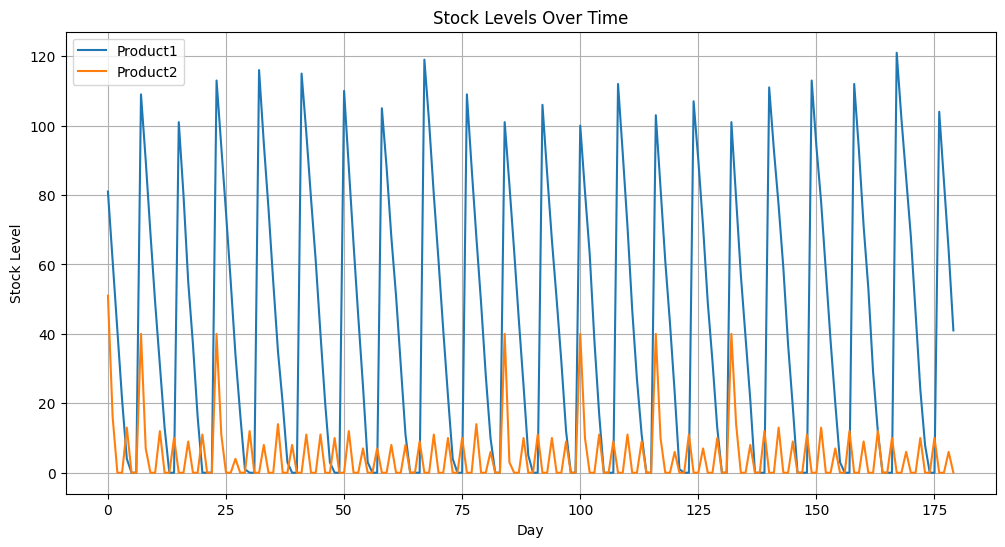

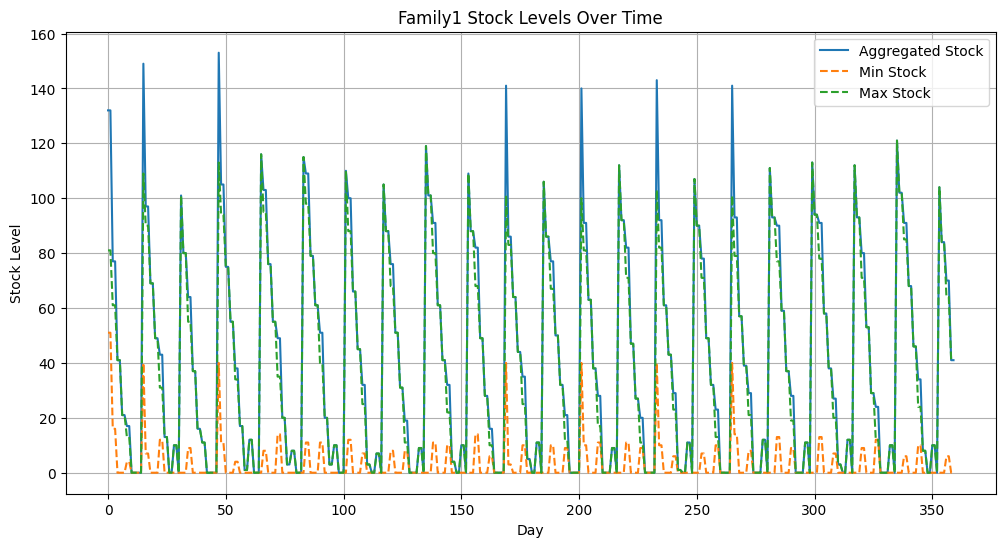

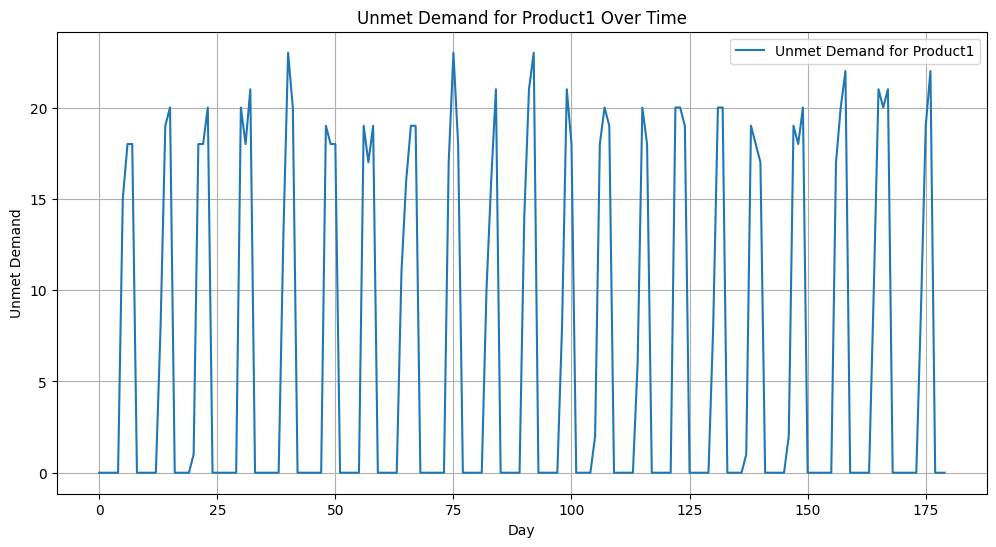

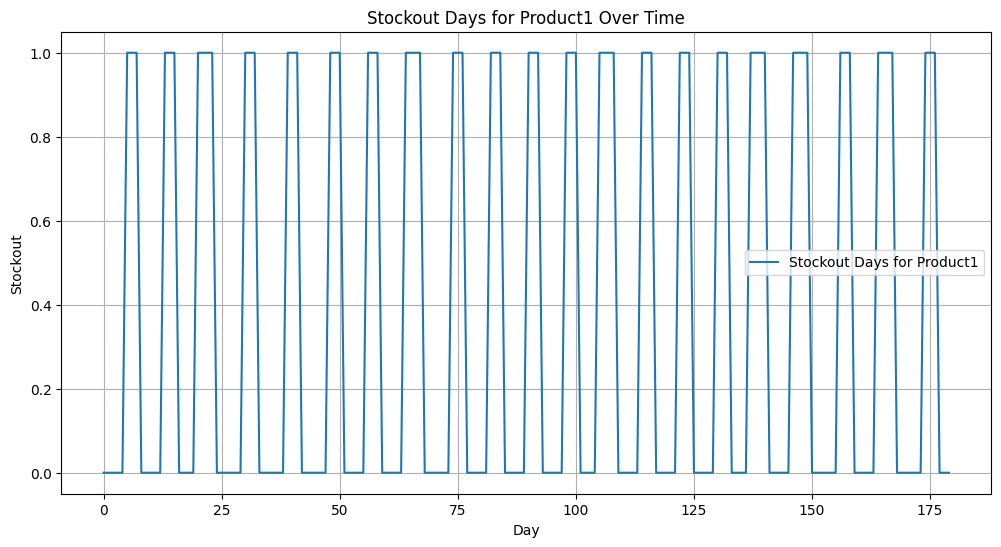

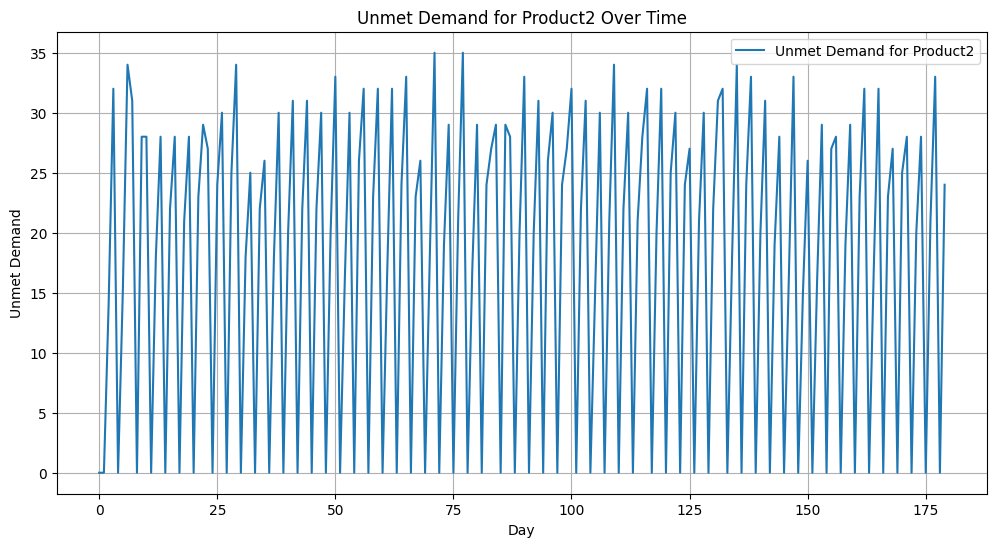

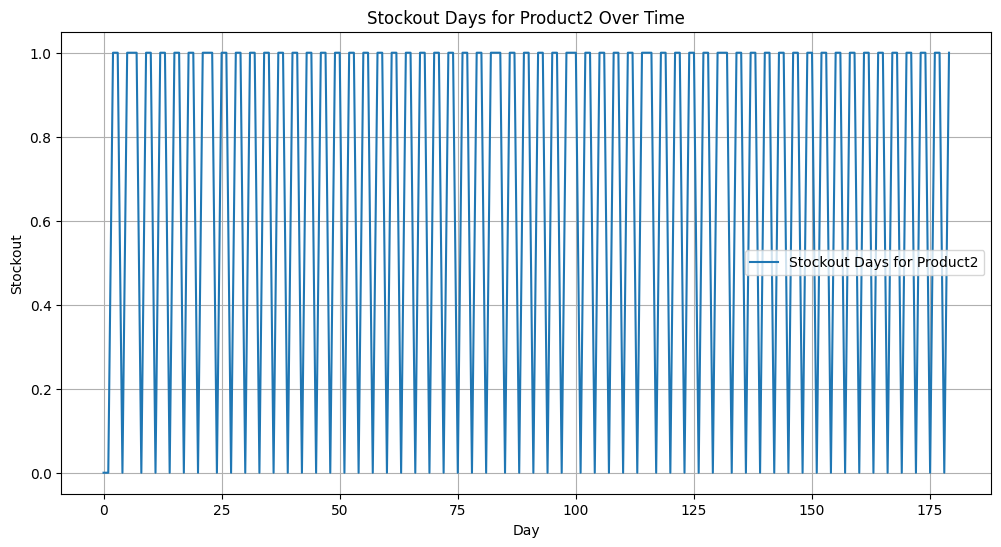

PermissionError: [Errno 13] Permission denied: 'stock_history.xlsx'

In [4]:
from base.simulation import Simulator
from base.inventory import Inventory, Order
from base.product import Product, ProductFamily, StockPolicy
from base.demand import DemandGenerator
import pandas as pd
import numpy as np

# Dados históricos dos últimos 10 dias para os produtos
historical_data_product1 = [20, 22, 18, 21, 19, 23, 17, 20, 22, 18]
historical_data_product2 = [30, 28, 35, 29, 33, 31, 30, 32, 34, 29]

# Família de produtos
family = ProductFamily(name='Family1')

# Parâmetros da política de estoque para os produtos
stock_policy_params1 = {'type': 'minmax', 'min_level': 50, 'max_level': 150, 'lead_time': 5}
stock_policy_params2 = {'type': 'lot_size', 'min_level': 30, 'max_level': 100, 'lead_time': 3, 'lot_size': 40}

# Produtos
product1 = Product(name='Product1', initial_stock=100, family=family, stock_policy_params=stock_policy_params1, historical_data=historical_data_product1)
product2 = Product(name='Product2', initial_stock=80, family=family, stock_policy_params=stock_policy_params2, historical_data=historical_data_product2)

family.add_product(product1)
family.add_product(product2)

# Estoque
inventory = Inventory(products=[product1, product2])

# Simulador
days = 180
simulator = Simulator(inventory, days)
df = simulator.run()    

# Salvar resultados
df.to_csv('stock_history.csv', index=False)
df.to_excel('stock_history.xlsx', index=False)

print("Simulação completa. Dados salvos em 'stock_history.csv' e 'stock_history.xlsx'.")

In [ ]:
# Defina os parâmetros do produto, política de estoque e demanda
family = ProductFamily("Electronics")
policy_params = {
    'type': 'minmax',
    'min_level': 50,
    'max_level': 200,
    'lead_time': 3,
    'lot_size': 100
}
demand_params = {
    'distribution_type': 'normal',
    'params': {'mean': 20, 'std_dev': 5}
}

# Crie uma instância do produto
product1 = Product(name="Product1", initial_stock=100, family=family, stock_policy_params=policy_params, demand_params=demand_params)

# Adicione o produto à família
family.add_product(product1)

# Crie uma lista de produtos
products = [product1]

# Instancie o simulador
simulator = Simulator(products, days=30)

# Execute a simulação e obtenha o DataFrame com as informações diárias
df_daily_info = simulator.run()

# Exiba o DataFrame
print(df_daily_info)


2